In [34]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

archivo = Path(r"C:\Users\user\Desktop\Labo 4\Young\dinamico\measurement_20260611_125450.csv")

df = pd.read_csv(
    archivo,
    skiprows=1,  # saltea la línea de comentario
)

df = df.rename(columns={
    "Time (s)": "tiempo",
    "Voltage (V)": "voltaje"
})

df.head()

,tiempo,voltaje
0,0.00000,1.476755
1,0.00004,1.476261
2,0.00008,1.476426
3,0.00012,1.477084
4,0.00016,1.477413


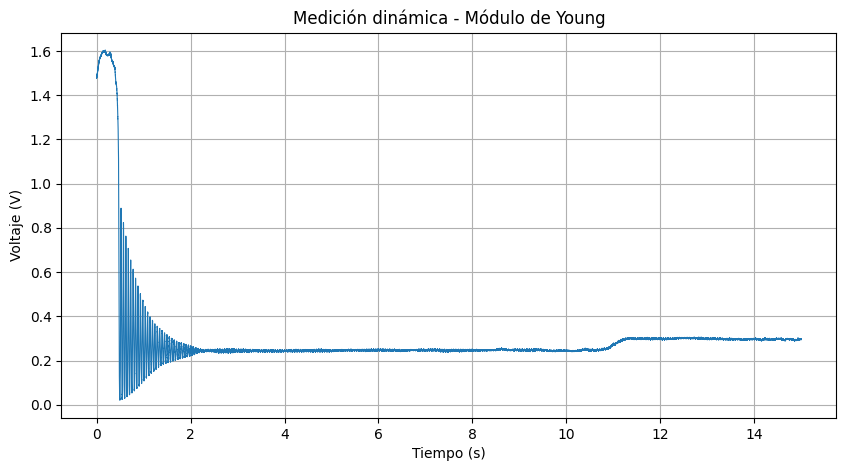

In [35]:


plt.figure(figsize=(10, 5))

plt.plot(df["tiempo"], df["voltaje"], linewidth=0.8)

plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (V)")
plt.title("Medición dinámica - Módulo de Young")
plt.grid(True)

plt.show()

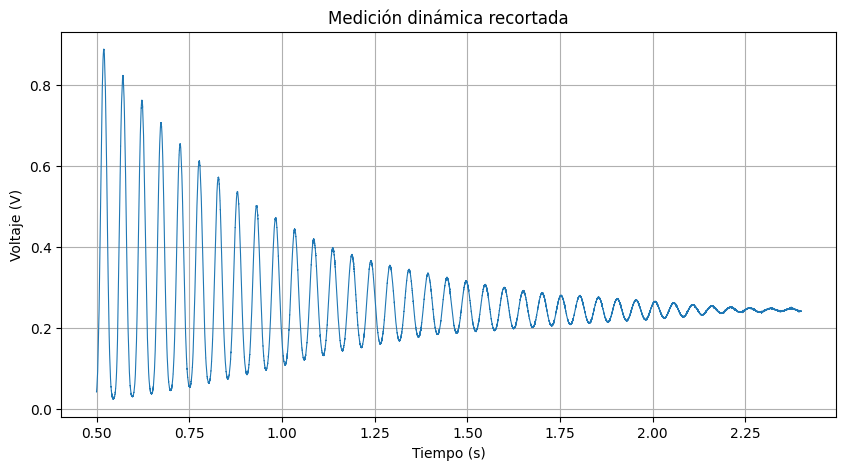

In [36]:
df_recorte = df[(df["tiempo"] >= 0.5) & (df["tiempo"] <= 2.4)].copy()

df_recorte.head()

plt.figure(figsize=(10, 5))

plt.plot(df_recorte["tiempo"], df_recorte["voltaje"], linewidth=0.8)

plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (V)")
plt.title("Medición dinámica recortada")
plt.grid(True)

plt.show()

In [37]:
df_recorte["tiempo_recortado"] = df_recorte["tiempo"] - df_recorte["tiempo"].iloc[0]

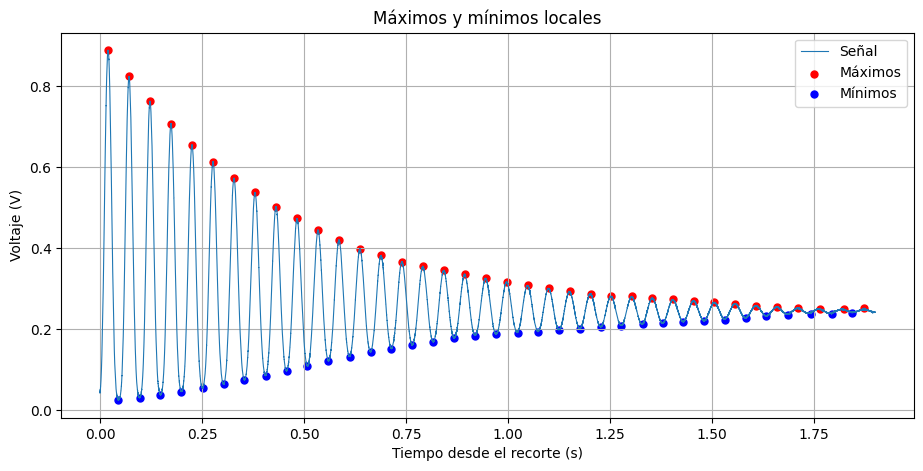

In [38]:
t = df_recorte["tiempo_recortado"].to_numpy()
v = df_recorte["voltaje"].to_numpy()

# Ajustá estos parámetros si detecta demasiados o muy pocos picos
peaks_max, props_max = find_peaks(
    v,
    prominence=0.01,
    distance=200
)

peaks_min, props_min = find_peaks(
    -v,
    prominence=0.01,
    distance=200
)

t_max = t[peaks_max]
v_max = v[peaks_max]

t_min = t[peaks_min]
v_min = v[peaks_min]

plt.figure(figsize=(11, 5))

plt.plot(t, v, linewidth=0.8, label="Señal")
plt.scatter(t_max, v_max, color="red", s=25, label="Máximos")
plt.scatter(t_min, v_min, color="blue", s=25, label="Mínimos")

plt.xlabel("Tiempo desde el recorte (s)")
plt.ylabel("Voltaje (V)")
plt.title("Máximos y mínimos locales")
plt.grid(True)
plt.legend()

plt.show()

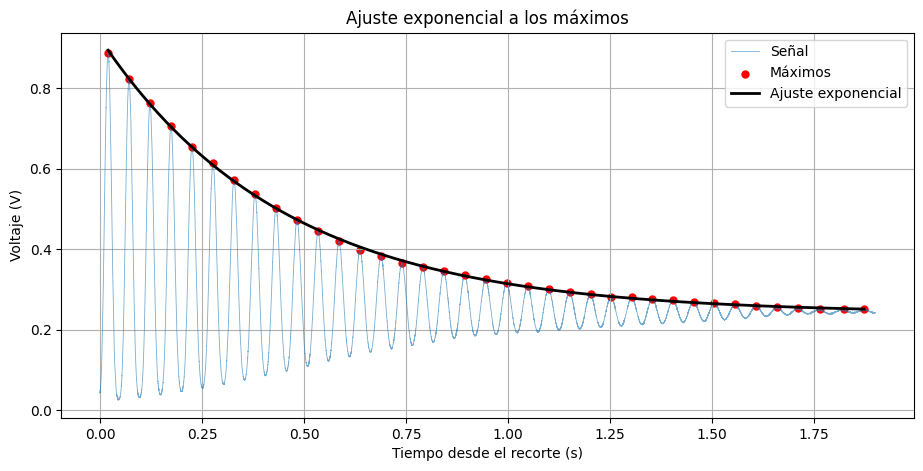

A = (0.68352 ± 0.0021) V
tau = (2.2308 ± 0.017) s
C = (0.24047 ± 0.0012) V


In [39]:
from scipy.optimize import curve_fit

def exp_decreciente(t, A, tau, C):
    return A * np.exp(-t * tau) + C

popt_max, pcov_max = curve_fit(
    exp_decreciente,
    t_max,
    v_max,
    p0=[v_max[0] - v_max[-1], 0.5, v_max[-1]]
)

A_max, alpha_max, C_max = popt_max

errores_max = np.sqrt(np.diag(pcov_max))

err_A_max, err_alpha_max, err_C_max = errores_max

t_fit = np.linspace(t_max.min(), t_max.max(), 1000)
v_fit_max = exp_decreciente(t_fit, A_max, alpha_max, C_max)

plt.figure(figsize=(11, 5))

plt.plot(t, v, linewidth=0.6, alpha=0.6, label="Señal")
plt.scatter(t_max, v_max, color="red", s=25, label="Máximos")
plt.plot(t_fit, v_fit_max, color="black", linewidth=2, label="Ajuste exponencial")

plt.xlabel("Tiempo desde el recorte (s)")
plt.ylabel("Voltaje (V)")
plt.title("Ajuste exponencial a los máximos")
plt.grid(True)
plt.legend()

plt.show()

print(f"A = ({A_max:.5g} ± {err_A_max:.2g}) V")
print(f"tau = ({alpha_max:.5g} ± {err_alpha_max:.2g}) s")
print(f"C = ({C_max:.5g} ± {err_C_max:.2g}) V")

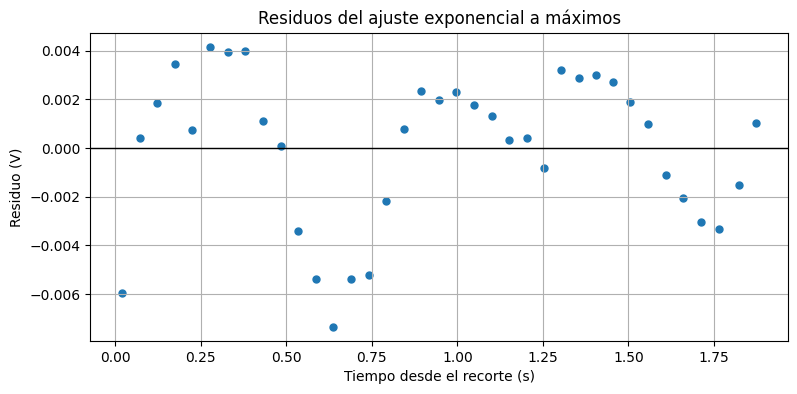

In [40]:
v_max_fit = exp_decreciente(t_max, A_max, tau_max, C_max)
residuos_max = v_max - v_max_fit

plt.figure(figsize=(9, 4))

plt.scatter(t_max, residuos_max, s=25)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Tiempo desde el recorte (s)")
plt.ylabel("Residuo (V)")
plt.title("Residuos del ajuste exponencial a máximos")
plt.grid(True)

plt.show()

In [41]:
t = df_recorte["tiempo_recortado"].to_numpy()
v = df_recorte["voltaje"].to_numpy()

# Sacamos el offset DC
v_centrada = v - np.mean(v)

# Paso temporal promedio
dt = np.mean(np.diff(t))

# FFT
fft = np.fft.rfft(v_centrada)
freq = np.fft.rfftfreq(len(v_centrada), d=dt)

# Amplitud normalizada
amp = 2 * np.abs(fft) / len(v_centrada)

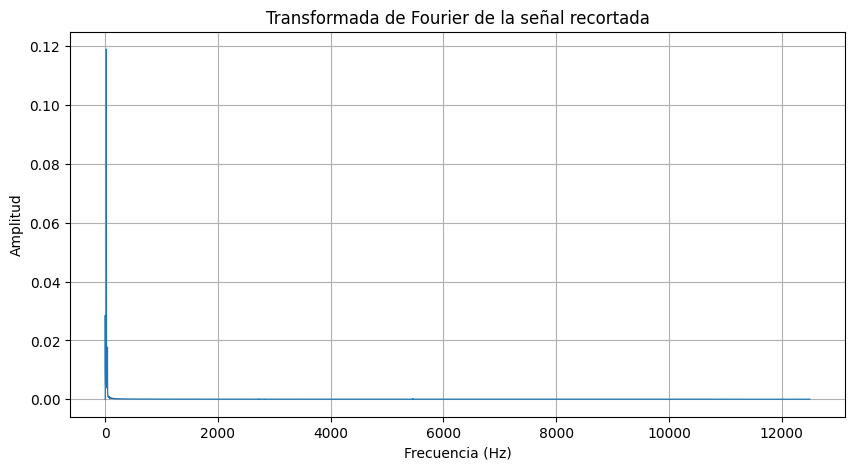

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(freq, amp, linewidth=0.9)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Transformada de Fourier de la señal recortada")
plt.grid(True)

plt.show()

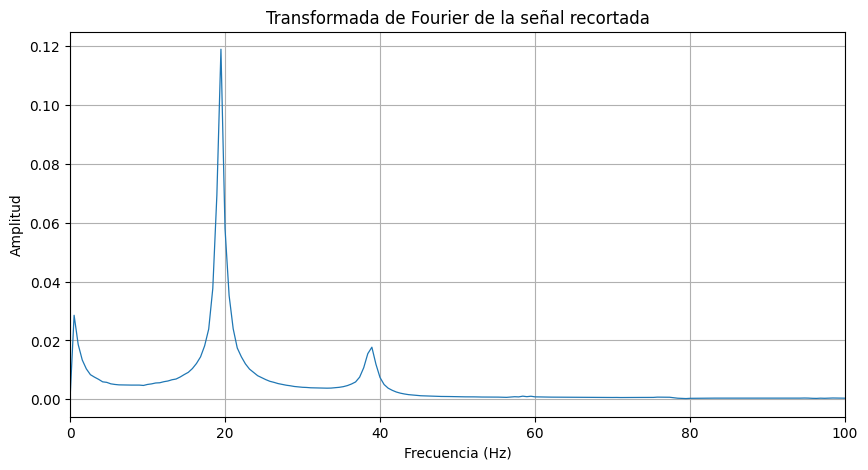

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(freq, amp, linewidth=0.9)

plt.xlim(0, 100)  # ajustá este rango según lo que veas
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Transformada de Fourier de la señal recortada")
plt.grid(True)

plt.show()

In [44]:
# Ignoramos frecuencia cero
idx_max = np.argmax(amp[1:]) + 1

frecuencia_dominante = freq[idx_max]
amplitud_dominante = amp[idx_max]

print(f"Frecuencia dominante = {frecuencia_dominante:.3f} Hz")
print(f"Amplitud dominante = {amplitud_dominante:.3g}")

Frecuencia dominante = 19.473 Hz
Amplitud dominante = 0.119


In [46]:
# -------------------------
# Frecuencia y decaimiento
# -------------------------

f1 = frecuencia_dominante

# Incertidumbre de frecuencia: resolución de la FFT
err_f1 = freq[1] - freq[0]

# Si el ajuste de máximos fue A exp(-t/tau) + C:
alpha = alpha_max
err_alpha = err_alpha_max

# -------------------------
# Datos experimentales en SI
# -------------------------

d = 5.00e-3
err_d = 0.05e-3

L = 29.5e-2
err_L = 0.1e-2

L_total = 50.0e-2
err_L_total = 0.1e-2

m = 82.76e-3
err_m = 0.01e-3

beta1 = 1.875104

# -------------------------
# Frecuencia angular natural
# -------------------------

omega0 = np.sqrt((2 * np.pi * f1)**2 + alpha**2)

# Propagación de incertidumbre para omega0
domega0_df1 = (4 * np.pi**2 * f1) / omega0
domega0_dalpha = alpha / omega0

err_omega0 = np.sqrt(
    (domega0_df1 * err_f1)**2
    + (domega0_dalpha * err_alpha)**2
)

# -------------------------
# Módulo de Young dinámico
# -------------------------

E = (
    64 * m * L**4 * omega0**2
    / (np.pi * d**4 * L_total * beta1**4)
)

# -------------------------
# Propagación de incertidumbre de E
# -------------------------

Q = omega0**2
err_Q = np.sqrt(
    (8 * np.pi**2 * f1 * err_f1)**2
    + (2 * alpha * err_alpha)**2
)

err_E = E * np.sqrt(
    (4 * err_d / d)**2
    + (err_L_total / L_total)**2
    + (err_m / m)**2
    + (4 * err_L / L)**2
    + (err_Q / Q)**2
)

# -------------------------
# Resultados
# -------------------------

print(f"f1 = ({f1:.5g} ± {err_f1:.2g}) Hz")
print(f"alpha = ({alpha:.5g} ± {err_alpha:.2g}) 1/s")
print(f"omega0 = ({omega0:.5g} ± {err_omega0:.2g}) rad/s")

print(f"E = ({E:.5g} ± {err_E:.2g}) Pa")
print(f"E = ({E/1e9:.5g} ± {err_E/1e9:.2g}) GPa")

f1 = (19.473 ± 0.53) Hz
alpha = (2.2308 ± 0.017) 1/s
omega0 = (122.37 ± 3.3) rad/s
E = (4.9496e+10 ± 3.4e+09) Pa
E = (49.496 ± 3.4) GPa
